### Plotting with seaborn. EDA of the salary data set

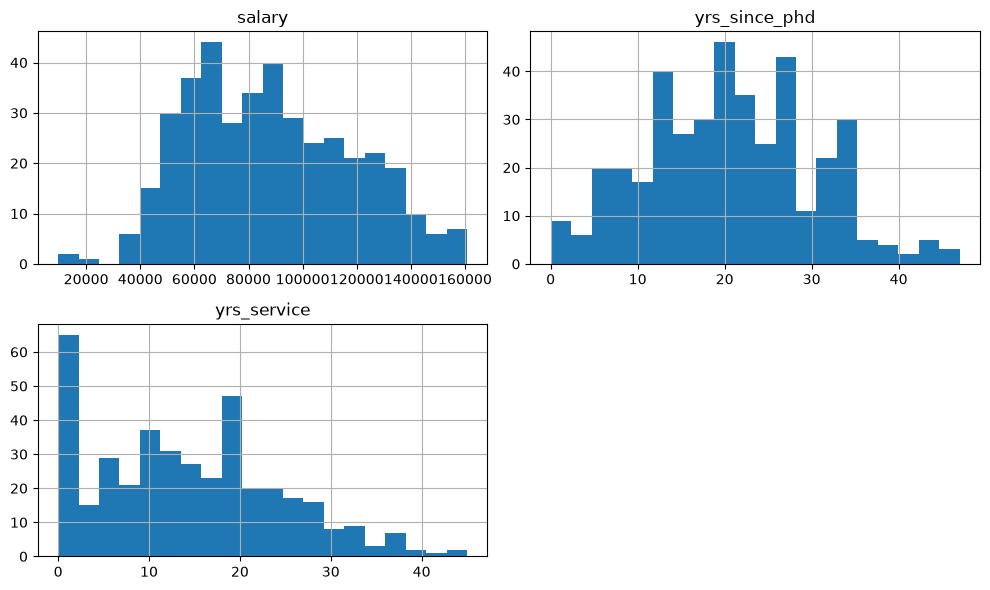

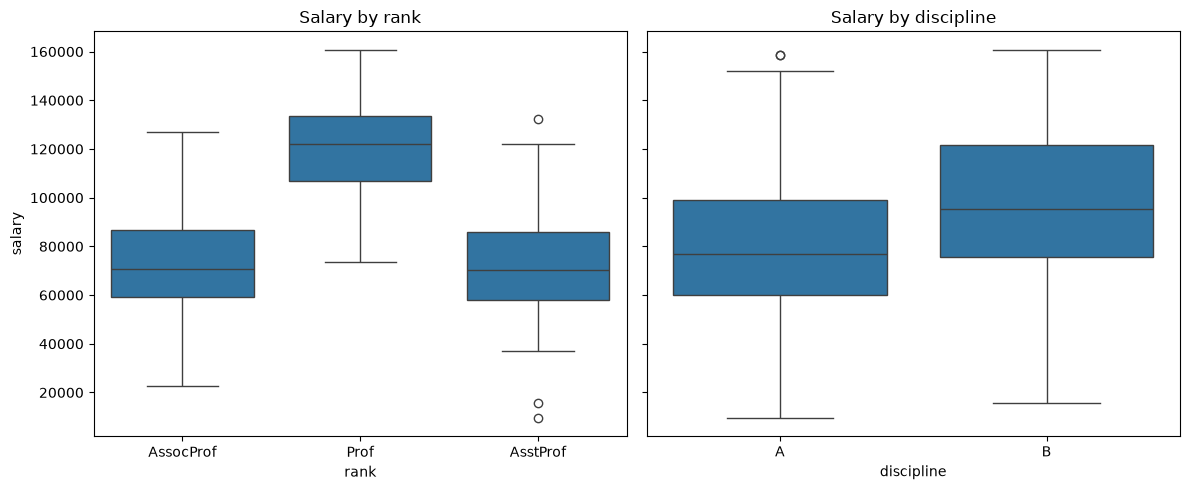

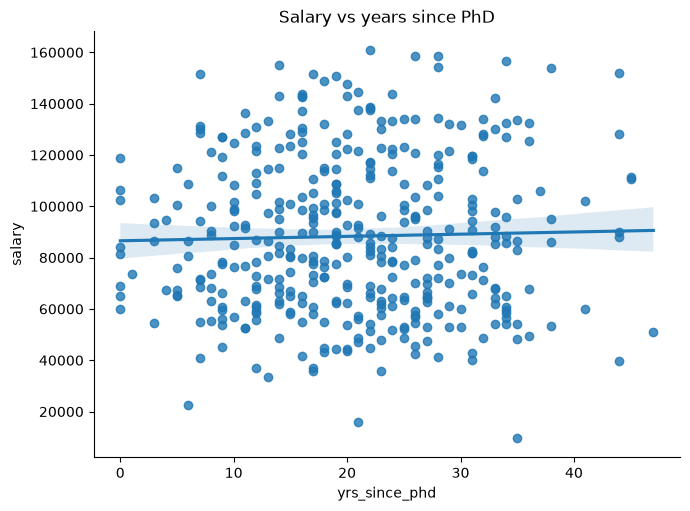

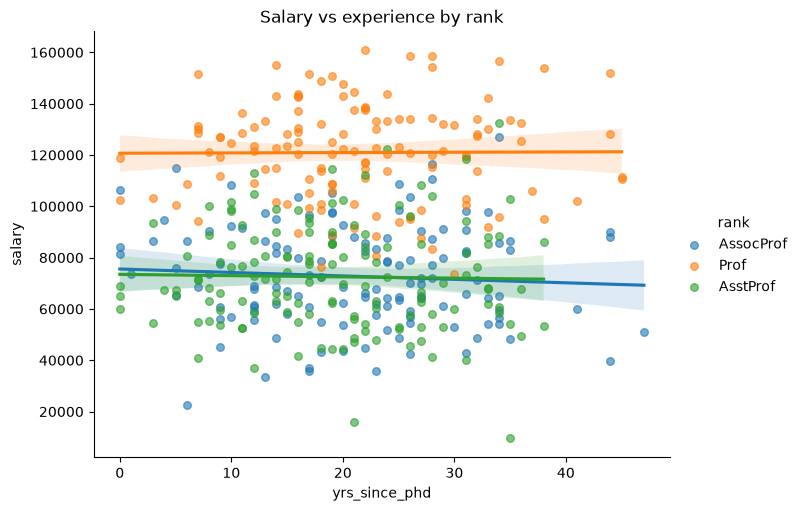

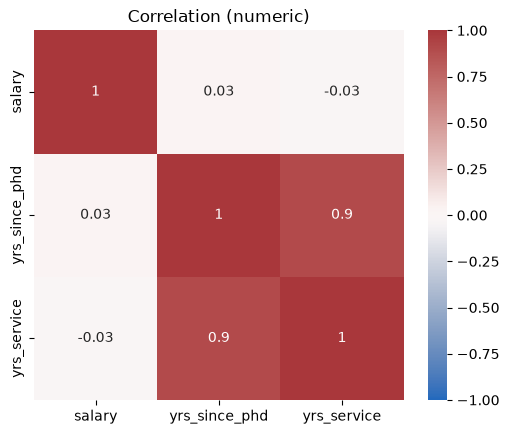

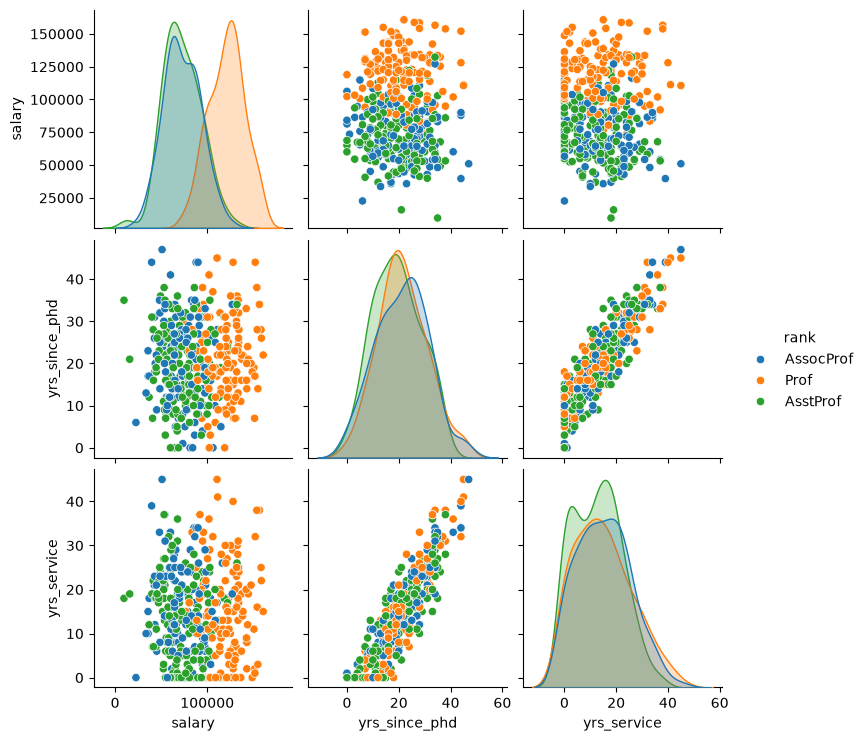

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/professors.csv") 

# 1) Distributions (numeric)
num_cols = ["salary","yrs_since_phd","yrs_service"]
df[num_cols].hist(figsize=(10,6), bins=20)
plt.tight_layout(); plt.show()

# 2) Boxplots by rank & discipline
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
sns.boxplot(data=df, x="rank", y="salary", ax=ax[0])
sns.boxplot(data=df, x="discipline", y="salary", ax=ax[1])
ax[0].set_title("Salary by rank"); ax[1].set_title("Salary by discipline")
plt.tight_layout(); plt.show()

# 3) Scatter + regression line (experience vs salary)
sns.lmplot(data=df, x="yrs_since_phd", y="salary", height=5, aspect=1.4)
plt.title("Salary vs years since PhD"); plt.show()

# 4) Colored regression by rank
sns.lmplot(data=df, x="yrs_since_phd", y="salary", hue="rank", height=5, aspect=1.4, scatter_kws=dict(s=30, alpha=.6))
plt.title("Salary vs experience by rank"); plt.show()

# 5) Correlation heatmap
corr = df[num_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="vlag", vmin=-1, vmax=1, square=True)
plt.title("Correlation (numeric)"); plt.show()

# 6) Pairplot for a quick overview
sns.pairplot(df[num_cols + ["rank"]], hue="rank")
plt.show()



### Multiple linear regression

In [4]:

# sklearn: design matrix, fit, and coefficients 
import pandas as pd
X = pd.get_dummies(
    df[["yrs_since_phd","yrs_service","rank","discipline","sex"]],
    drop_first=True
)
y = df["salary"]

lr = LinearRegression().fit(X, y)

print(lr.coef_  )  # coefficients
print(lr.intercept_)  # intercept


# intercept + coefficients 
coef_df = pd.DataFrame({"coef": lr.coef_}, index=X.columns).round(1)
coef_df = coef_df.sort_index()  # sort by index (feature name)

#print("Intercept:", round(lr.intercept_, 1))
display(coef_df)
print("R^2:", lr.score(X, y))


[  710.14345342  -745.79060447 -1914.67643498 46436.98460837
 13830.34587724   332.41350467]
63495.56991022939


,coef
discipline_B,13830.3
rank_AsstProf,-1914.7
rank_Prof,46437.0
sex_Male,332.4
yrs_service,-745.8
yrs_since_phd,710.1


R^2: 0.6298902465853387


In [ ]:
#  PREDICT for a list of observations --------------------------------------
new_obs = [
    {"yrs_since_phd": 5,  "yrs_service": 3,    "rank": "AsstProf",  "discipline": "A"},
    {"yrs_since_phd": 12, "yrs_service": 8,  "rank": "AssocProf", "discipline": "B"},
    {"yrs_since_phd": 25, "yrs_service": 18,  "rank": "Prof",      "discipline": "A"},
]
# or read the data from a file, like we read the original data: df = pd.read_csv("../data/professors.csv")


new_df = pd.DataFrame(new_obs)
X_new = pd.get_dummies(new_df, drop_first=True)
X_cols = X.columns  
# Align dummy columns to training design matrix. 
X_new = X_new.reindex(columns=X_cols, fill_value=0)

pred = lr.predict(X_new)
new_df["pred_salary"] = pred.round(0)
new_df

,yrs_since_phd,yrs_service,publications,rank,discipline,pred_salary
0,5,3,8,AsstProf,A,62894.0
1,12,8,20,AssocProf,B,79881.0
2,25,18,40,Prof,A,114262.0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

# 1) Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2) Fit on TRAIN only
lr = LinearRegression().fit(X_train, y_train)

# 3) Evaluate on TEST
y_pred = lr.predict(X_test)
r2  = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
print(r2)
print(rmse)


0.6339564689806112
376822181.7755817


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error

# --- K-fold CV ---
cv = KFold(n_splits=10, shuffle=True, random_state=0)

# R^2 across folds
cv_r2 = cross_val_score(lr, X, y, cv=cv, scoring="r2")
print(f"CV R^2 (mean ± sd): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# RMSE across folds (use negative MSE scores)
cv_mse = cross_val_score(lr, X, y, cv=cv, scoring="neg_mean_squared_error")
#cross_val_score always tries to maximize the score (higher = better), hence neg
cv_rmse = np.sqrt(-cv_mse)
print(f"CV RMSE (mean ± sd): {cv_rmse.mean():.1f} ± {cv_rmse.std():.1f}")

# Optional: cross-validated predictions for diagnostics
y_pred_cv = cross_val_predict(lr, X, y, cv=cv)
resid_cv = y - y_pred_cv
print("CV residuals summary (mean, sd):", resid_cv.mean().round(2), resid_cv.std().round(2))


CV R^2 (mean ± sd): 0.587 ± 0.092
CV RMSE (mean ± sd): 18699.5 ± 1825.2
CV residuals summary (mean, sd): -23.31 18811.92


Exercise: 
1. Select a different subset of variables as predictors. Compare performance of the original model and the model of your choice using CV RMSE. 